# SignTalk: Conversational AI for Deaf & Mute Users
### Continuous Sign Language Recognition → BiLSTM Classifier → Claude LLM
**Runtime:** A100 GPU | **Dataset:** WLASL top-25 signs

---
**Sections**
0. Install & Imports
1. Mount Drive & Paths
2. Extract Keypoints (MediaPipe Tasks API)
3. Build Dataset
4. Train BiLSTM
5. Evaluate
6. Save Model
7. LLM Setup (Claude)
8. Gradio Demo


# @title Section 0 — Install & Imports
# Run once per runtime. Restart kernel after if prompted.


In [ ]:
!pip install -q mediapipe torch torchvision gradio opencv-python scikit-learn matplotlib seaborn tqdm yt-dlp anthropic


In [ ]:
import os, json, random, time, threading, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'MediaPipe version: {mp.__version__}')


Device: cuda
MediaPipe version: 0.10.35


# @title Section 1 — Mount Drive & Config


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Path config ──────────────────────────────────────────────
DRIVE_BASE  = '/content/drive/MyDrive/SignTalk'
WLASL_JSON  = '/content/WLASL/start_kit/WLASL_v0.3.json'
VIDEO_DIR   = os.path.join(DRIVE_BASE, 'videos')
KP_DIR      = os.path.join(DRIVE_BASE, 'keypoints')
MODEL_DIR   = os.path.join(DRIVE_BASE, 'mediapipe_models')
CKPT_DIR    = os.path.join(DRIVE_BASE, 'checkpoints')

for d in [VIDEO_DIR, KP_DIR, MODEL_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Hyper-parameters ──────────────────────────────────────────
TOP_N       = 25       # number of sign classes
SEQ_LEN     = 60       # frames the model expects
FEAT_DIM    = 258      # 33*4 pose + 21*3 left + 21*3 right
HIDDEN      = 256
NUM_LAYERS  = 2
DROPOUT     = 0.4
EPOCHS      = 40
BATCH       = 32
LR          = 1e-3
COLLECT_FRAMES = 30    # frames captured before classify

print('Paths ready.')


Paths ready.


# @title Section 2 — MediaPipe Tasks Setup


In [ ]:
# ── Download MediaPipe model files ───────────────────────────────────────────
# Files are saved to Drive so they persist across sessions.
# The cell re-downloads if a file is missing OR suspiciously small (<100 KB).

POSE_MODEL = os.path.join(MODEL_DIR, 'pose_landmarker_heavy.task')
HAND_MODEL = os.path.join(MODEL_DIR, 'hand_landmarker.task')

POSE_URL = ('https://storage.googleapis.com/mediapipe-models/'
            'pose_landmarker/pose_landmarker_heavy/float16/1/'
            'pose_landmarker_heavy.task')
HAND_URL = ('https://storage.googleapis.com/mediapipe-models/'
            'hand_landmarker/hand_landmarker/float16/1/'
            'hand_landmarker.task')

def _needs_download(fpath, min_bytes=100_000):
    return (not os.path.exists(fpath)) or (os.path.getsize(fpath) < min_bytes)

def _download(url, dest):
    print(f'Downloading {os.path.basename(dest)} ...')
    ret = os.system(f'wget --no-verbose --show-progress -O "{dest}" "{url}"')
    if ret != 0 or _needs_download(dest):
        raise RuntimeError(
            f'Download failed for {url}.\n'
            'Check your internet connection or try: '
            f'!wget -O "{dest}" "{url}"')
    print(f'  -> {os.path.getsize(dest):,} bytes')

if _needs_download(POSE_MODEL):
    _download(POSE_URL, POSE_MODEL)
else:
    print(f'Pose model already on Drive ({os.path.getsize(POSE_MODEL):,} bytes)')

if _needs_download(HAND_MODEL):
    _download(HAND_URL, HAND_MODEL)
else:
    print(f'Hand model already on Drive ({os.path.getsize(HAND_MODEL):,} bytes)')

print('\nAll model files ready.')


Pose model already on Drive (30,664,242 bytes)
Hand model already on Drive (7,819,105 bytes)

All model files ready.


In [ ]:
# Create detectors ONCE — reused across all video processing
_lock = threading.Lock()

def _make_pose_det():
    return mp_vision.PoseLandmarker.create_from_options(
        mp_vision.PoseLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=POSE_MODEL),
            running_mode=mp_vision.RunningMode.IMAGE))

def _make_hand_det():
    return mp_vision.HandLandmarker.create_from_options(
        mp_vision.HandLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=HAND_MODEL),
            running_mode=mp_vision.RunningMode.IMAGE,
            num_hands=2))

_pose_det = _make_pose_det()
_hand_det = _make_hand_det()
print('Detectors ready.')


Detectors ready.


In [ ]:
def _extract_kp(frame):
    """Extract 258-dim keypoint vector from a single BGR frame."""
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    with _lock:
        pr = _pose_det.detect(mp_img)
        hr = _hand_det.detect(mp_img)

    # Pose: 33 landmarks x (x,y,z,visibility)
    if pr.pose_landmarks:
        pose = np.array([[l.x, l.y, l.z, l.visibility]
                         for l in pr.pose_landmarks[0]], dtype=np.float32).flatten()
    else:
        pose = np.zeros(33 * 4, dtype=np.float32)

    # Hands: 21 landmarks x (x,y,z)
    left_hand  = np.zeros(21 * 3, dtype=np.float32)
    right_hand = np.zeros(21 * 3, dtype=np.float32)
    if hr.hand_landmarks:
        for i, handedness in enumerate(hr.handedness):
            label = handedness[0].category_name  # 'Left' or 'Right'
            kp = np.array([[l.x, l.y, l.z] for l in hr.hand_landmarks[i]],
                          dtype=np.float32).flatten()
            if label == 'Left':
                left_hand = kp
            else:
                right_hand = kp

    return np.concatenate([pose, left_hand, right_hand])  # shape (258,)

# Quick sanity check
dummy = np.zeros((480, 640, 3), dtype=np.uint8)
vec = _extract_kp(dummy)
print(f'Feature vector shape: {vec.shape}')  # expect (258,)


Feature vector shape: (258,)


In [ ]:
def video_to_sequence(video_path, seq_len=SEQ_LEN):
    """Read a video and return a (seq_len, FEAT_DIM) float32 array."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()

    if len(frames) == 0:
        return None

    kps = []
    for f in frames:
        try:
            kps.append(_extract_kp(f))
        except Exception:
            kps.append(np.zeros(FEAT_DIM, dtype=np.float32))

    arr = np.array(kps, dtype=np.float32)  # (T, 258)

    # Interpolate to exactly seq_len frames
    if len(arr) >= seq_len:
        idx = np.linspace(0, len(arr) - 1, seq_len, dtype=int)
        return arr[idx]
    idx = np.linspace(0, len(arr) - 1, seq_len)
    lo  = np.floor(idx).astype(int)
    hi  = np.minimum(lo + 1, len(arr) - 1)
    frac = (idx - lo)[:, None]
    return (arr[lo] * (1 - frac) + arr[hi] * frac).astype(np.float32)


# @title Section 3 — Build Dataset from WLASL


In [ ]:
# Clone WLASL dataset repo (contains JSON + starter kit)
# Skip if already cloned
import os

if not os.path.exists('/content/WLASL'):
    print('Cloning WLASL repo...')
    ret = os.system('git clone --depth 1 https://github.com/dxli94/WLASL.git /content/WLASL')
    if ret != 0:
        raise RuntimeError('git clone failed — check your internet connection.')
else:
    print('WLASL repo already present.')

# Confirm the JSON is there
assert os.path.exists(WLASL_JSON), f'JSON not found at {WLASL_JSON}'
print(f'WLASL JSON ready: {WLASL_JSON}')


WLASL repo already present.
WLASL JSON ready: /content/WLASL/start_kit/WLASL_v0.3.json


In [ ]:
# Load WLASL JSON and pick top-N signs
with open(WLASL_JSON) as f:
    wlasl_data = json.load(f)

# Sort by video count, take top N
sign_counts = [(entry['gloss'], len(entry['instances'])) for entry in wlasl_data]
sign_counts.sort(key=lambda x: -x[1])
top_signs = [s for s, _ in sign_counts[:TOP_N]]
SIGN2IDX = {s: i for i, s in enumerate(top_signs)}
IDX2SIGN = {i: s for s, i in SIGN2IDX.items()}

print(f'Top {TOP_N} signs: {top_signs}')
print(f'Sign-to-index mapping created ({len(SIGN2IDX)} classes)')


Top 25 signs: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin', 'deaf', 'fine', 'help', 'no', 'thin', 'walk', 'year', 'yes', 'all', 'black', 'cool', 'finish', 'hot', 'like', 'many']
Sign-to-index mapping created (25 classes)


In [ ]:
# Build sequences — optimized version
# Iterates only top-25 signs, caps at 30 videos/sign, strides frames

MAX_PER_SIGN = 30   # max videos per sign class
FRAME_STRIDE = 2    # sample every 2nd frame (2x faster, minimal quality loss)

# Build a lookup: gloss -> instances  (so we don't walk all 2000 entries)
gloss_to_instances = {e['gloss']: e['instances'] for e in wlasl_data}

X, y = [], []
missing = 0

for gloss in tqdm(top_signs, desc='Processing signs'):
    label = SIGN2IDX[gloss]
    sign_dir = os.path.join(VIDEO_DIR, gloss)
    instances = gloss_to_instances.get(gloss, [])[:MAX_PER_SIGN]

    for inst in instances:
        vid_id = str(inst['video_id'])
        found = None
        for ext in ['.mp4', '.avi', '.mov']:
            p = os.path.join(sign_dir, vid_id + ext)
            if os.path.exists(p):
                found = p
                break
        if found is None:
            missing += 1
            continue

        kp_path = os.path.join(KP_DIR, f'{gloss}_{vid_id}.npy')
        if os.path.exists(kp_path):
            seq = np.load(kp_path)
        else:
            # Read frames with stride
            cap = cv2.VideoCapture(found)
            frames = []
            idx = 0
            while True:
                ok, frame = cap.read()
                if not ok:
                    break
                if idx % FRAME_STRIDE == 0:
                    frames.append(frame)
                idx += 1
            cap.release()

            if not frames:
                missing += 1
                continue

            kps = []
            for fr in frames:
                try:
                    kps.append(_extract_kp(fr))
                except Exception:
                    kps.append(np.zeros(FEAT_DIM, dtype=np.float32))

            arr = np.array(kps, dtype=np.float32)
            # Interpolate to SEQ_LEN
            if len(arr) >= SEQ_LEN:
                idxs = np.linspace(0, len(arr)-1, SEQ_LEN, dtype=int)
                seq = arr[idxs]
            else:
                idxs = np.linspace(0, len(arr)-1, SEQ_LEN)
                lo = np.floor(idxs).astype(int)
                hi = np.minimum(lo+1, len(arr)-1)
                frac = (idxs - lo)[:, None]
                seq = (arr[lo]*(1-frac) + arr[hi]*frac).astype(np.float32)

            np.save(kp_path, seq)

        X.append(seq)
        y.append(label)

print(f'Total samples: {len(X)} | Missing/skipped: {missing}')

Processing signs:   0%|          | 0/25 [00:00<?, ?it/s]

Total samples: 138 | Missing/skipped: 451


In [ ]:
# Train/val split
X = np.array(X, dtype=np.float32)  # (N, 60, 258)
y = np.array(y, dtype=np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train)} | Val: {len(X_val)}')
print(f'Feature shape: {X_train.shape}')


Train: 110 | Val: 28
Feature shape: (110, 60, 258)


# @title Section 4 — BiLSTM with Attention


In [ ]:
class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_ds = SignDataset(X_train, y_train)
val_ds   = SignDataset(X_val,   y_val)
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
print(f'Loaders ready | {len(train_dl)} train batches, {len(val_dl)} val batches')


Loaders ready | 4 train batches, 1 val batches


In [ ]:
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    def forward(self, h):  # h: (B, T, dim)
        w = torch.softmax(self.attn(h), dim=1)  # (B, T, 1)
        return (h * w).sum(dim=1)               # (B, dim)


class BiLSTMSign(nn.Module):
    def __init__(self, feat_dim, hidden, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0)
        self.norm   = nn.LayerNorm(hidden * 2)
        self.pool   = AttentionPool(hidden * 2)
        self.drop   = nn.Dropout(dropout)
        self.fc     = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):  # x: (B, T, feat_dim)
        h, _ = self.lstm(x)         # (B, T, hidden*2)
        h    = self.norm(h)
        h    = self.pool(h)         # (B, hidden*2)
        h    = self.drop(h)
        return self.fc(h)           # (B, num_classes)


model = BiLSTMSign(FEAT_DIM, HIDDEN, NUM_LAYERS, TOP_N, DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model params: {total_params:,}')
print(model)


Model params: 2,648,090
BiLSTMSign(
  (lstm): LSTM(258, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (pool): AttentionPool(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=25, bias=True)
)


# @title Section 5 — Train


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_dl), epochs=EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # -- train --
    model.train()
    run_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        run_loss += loss.item() * len(yb)

    train_loss = run_loss / len(train_ds)

    # -- validate --
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += criterion(logits, yb).item() * len(yb)
            correct  += (logits.argmax(1) == yb).sum().item()

    val_loss /= len(val_ds)
    val_acc   = correct / len(val_ds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, 'best_model.pth'))

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{EPOCHS} | '
              f'train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | '
              f'val_acc={val_acc:.3f}')

print(f'Best val accuracy: {best_val_acc:.3f}')


Ep   1/40 | train_loss=3.2004 | val_loss=3.0754 | val_acc=0.071
Ep   5/40 | train_loss=2.8987 | val_loss=2.8962 | val_acc=0.107
Ep  10/40 | train_loss=2.6977 | val_loss=2.8405 | val_acc=0.107
Ep  15/40 | train_loss=2.4300 | val_loss=3.2968 | val_acc=0.143
Ep  20/40 | train_loss=2.2324 | val_loss=3.0502 | val_acc=0.286
Ep  25/40 | train_loss=1.8843 | val_loss=3.3123 | val_acc=0.179
Ep  30/40 | train_loss=1.6087 | val_loss=3.5747 | val_acc=0.143
Ep  35/40 | train_loss=1.3894 | val_loss=3.5264 | val_acc=0.143
Ep  40/40 | train_loss=1.3310 | val_loss=3.5488 | val_acc=0.179
Best val accuracy: 0.286


# @title Section 6 — Evaluate


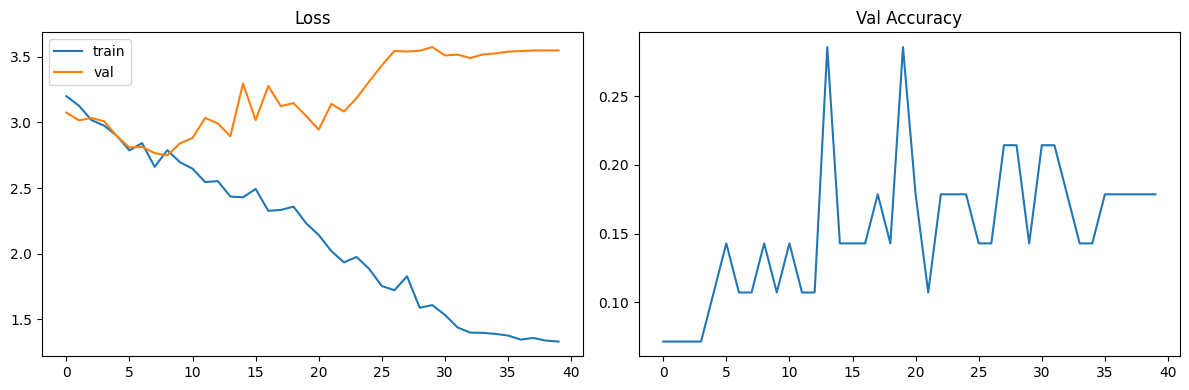

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'best_model.pth'), map_location=device))
model.eval()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_acc'])
axes[1].set_title('Val Accuracy')
plt.tight_layout(); plt.show()


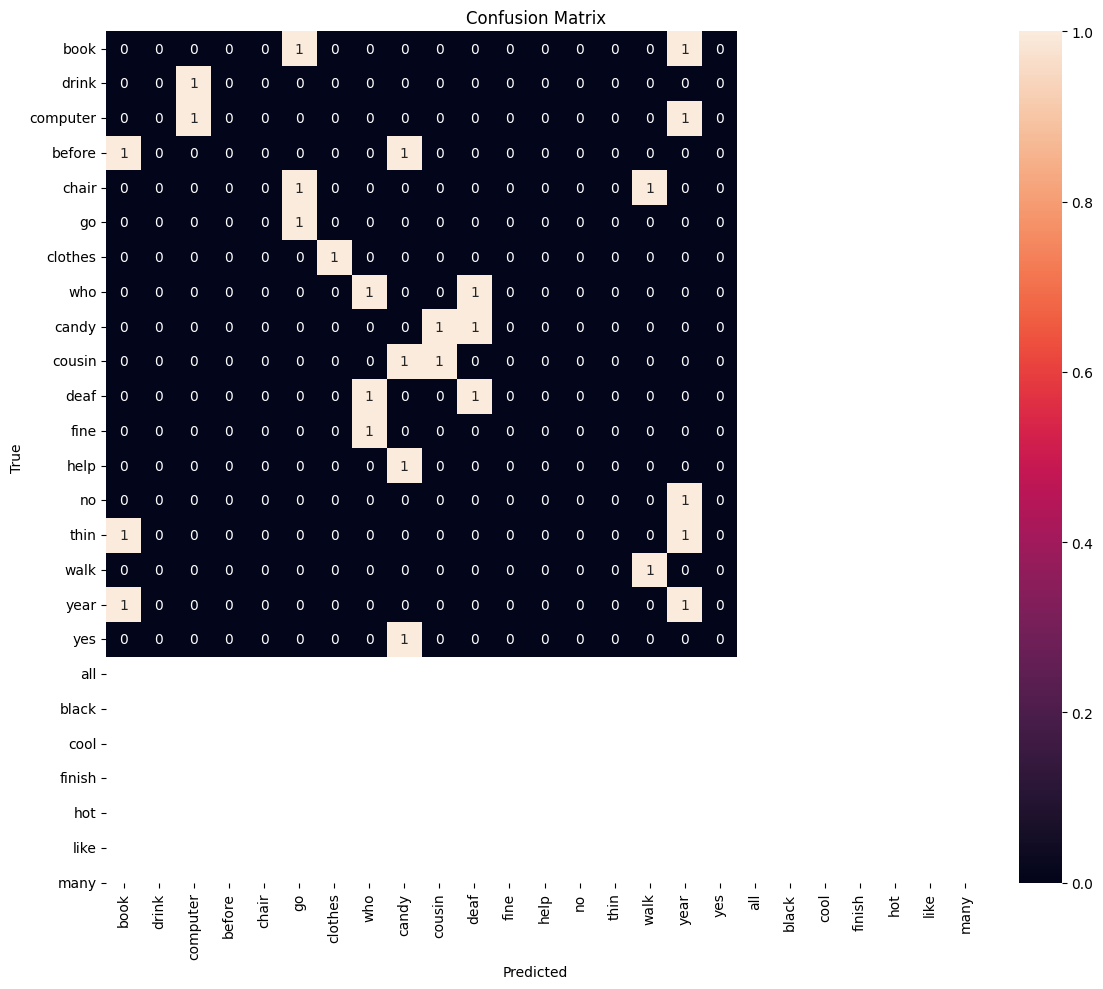

ValueError: Number of classes, 18, does not match size of target_names, 25. Try specifying the labels parameter

In [ ]:
# Confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_dl:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=[IDX2SIGN[i] for i in range(TOP_N)],
            yticklabels=[IDX2SIGN[i] for i in range(TOP_N)])
ax.set_title('Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=[IDX2SIGN[i] for i in range(TOP_N)]))


# @title Section 7 — LLM Chat (Claude)
> **Security note:** Store your API key in Colab Secrets (key icon in left sidebar) under the name `ANTHROPIC_KEY`. Never hard-code keys.


In [ ]:
from google.colab import userdata
import anthropic

ANTHROPIC_KEY = userdata.get('ANTHROPIC_KEY')
if not ANTHROPIC_KEY:
    raise ValueError('Add ANTHROPIC_KEY to Colab Secrets (left sidebar key icon).')

claude_client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)

SYSTEM_PROMPT = (
    'You are a helpful assistant for a Deaf or mute user. '
    'You receive recognized American Sign Language (ASL) signs as input and '
    'respond with short, friendly, natural conversational replies in English. '
    'Keep responses under 3 sentences.'
)

conversation_history = []

def reset_conversation():
    global conversation_history
    conversation_history = []

def chat(sign_word: str) -> str:
    """Send a recognized sign to Claude and return the response text."""
    global conversation_history
    conversation_history.append({'role': 'user', 'content': sign_word})
    resp = claude_client.messages.create(
        model='claude-opus-4-6',
        max_tokens=200,
        system=SYSTEM_PROMPT,
        messages=conversation_history)
    reply = resp.content[0].text
    conversation_history.append({'role': 'assistant', 'content': reply})
    return reply

# Quick test
print('LLM test:', chat('hello'))
reset_conversation()


# @title Section 8 — Gradio Demo


In [ ]:
import gradio as gr
print(f'Gradio version: {gr.__version__}')


In [ ]:
# ── Frame buffer (shared between webcam thread & classify fn) ──────────
frame_buf = []
_buf_lock = threading.Lock()


def _buf_to_seq(buf):
    """Interpolate list of keypoint arrays to exactly SEQ_LEN frames."""
    arr = np.array(buf, dtype=np.float32)  # (T, 258)
    if len(arr) >= SEQ_LEN:
        idx = np.linspace(0, len(arr) - 1, SEQ_LEN, dtype=int)
        return arr[idx]
    idx  = np.linspace(0, len(arr) - 1, SEQ_LEN)
    lo   = np.floor(idx).astype(int)
    hi   = np.minimum(lo + 1, len(arr) - 1)
    frac = (idx - lo)[:, None]
    return (arr[lo] * (1 - frac) + arr[hi] * frac).astype(np.float32)


def process_webcam_frame(image):
    """Called by Gradio streaming input — appends keypoints to buffer."""
    global frame_buf
    if image is None:
        return image
    try:
        bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        kp  = _extract_kp(bgr)
        with _buf_lock:
            frame_buf.append(kp)
            if len(frame_buf) > 120:  # cap buffer size
                frame_buf = frame_buf[-120:]
    except Exception as e:
        print(f'Frame processing error: {e}')
    return image  # pass through for display


def classify_fn(chat_log):
    """Classify buffered frames and get LLM response."""
    global frame_buf

    with _buf_lock:
        current_buf = list(frame_buf[-COLLECT_FRAMES:])
        frame_buf = []

    if len(current_buf) < 10:
        msg = f'Not enough frames ({len(current_buf)}) — wave your hands and try again!'
        return msg, '', chat_log, chat_log  # 4 outputs

    seq = _buf_to_seq(current_buf)  # (SEQ_LEN, FEAT_DIM)
    with torch.no_grad():
        inp   = torch.FloatTensor(seq).unsqueeze(0).to(device)
        probs = torch.softmax(model(inp), dim=1)
        conf, pred = probs.max(1)

    sign       = IDX2SIGN[pred.item()]
    confidence = conf.item()

    if confidence < 0.35:
        msg = f'Low confidence ({confidence:.0%}) — try again'
        return msg, '', chat_log, chat_log  # 4 outputs

    try:
        response = chat(sign)
    except Exception as e:
        response = f'(LLM error: {e})'

    new_chat = chat_log + [(f'[Signed: {sign.upper()}] ({confidence:.0%})', response)]
    return f'Detected: {sign.upper()} ({confidence:.0%})', response, new_chat, new_chat


def clear_fn(chat_log):
    """Clear buffer and conversation history."""
    global frame_buf
    with _buf_lock:
        frame_buf = []
    reset_conversation()
    return 'Cleared!', '', [], []  # 4 outputs


In [ ]:
# ── Build Gradio UI ─────────────────────────────────────────────────────
with gr.Blocks(title='SignTalk', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# SignTalk\nASL -> Claude Conversation Demo')

    with gr.Row():
        with gr.Column(scale=1):
            webcam = gr.Image(
                sources=['webcam'],
                streaming=True,
                label='Webcam Feed')
            with gr.Row():
                classify_btn = gr.Button('Classify Sign', variant='primary')
                clear_btn    = gr.Button('Clear', variant='secondary')
            status_md  = gr.Textbox(label='Status', interactive=False)
            response_tb = gr.Textbox(label='Claude Response', interactive=False)

        with gr.Column(scale=1):
            chatbot = gr.Chatbot(label='Conversation')

    chat_state = gr.State([])

    # Wire streaming: each frame -> process_webcam_frame (no state needed)
    webcam.stream(
        fn=process_webcam_frame,
        inputs=[webcam],
        outputs=[webcam])

    # Classify button
    classify_btn.click(
        fn=classify_fn,
        inputs=[chat_state],
        outputs=[status_md, response_tb, chatbot, chat_state])

    # Clear button
    clear_btn.click(
        fn=clear_fn,
        inputs=[chat_state],
        outputs=[status_md, response_tb, chatbot, chat_state])

demo.launch(share=True, debug=True)
